
# Q2. Robust Circle Detection using Hough Transform

This notebook performs **circle detection using the Hough Transform** on an image containing multiple circular objects.

The experiment investigates:

1. Preprocessing and edge detection.
2. Circle detection using the Hough Transform.
3. The effect of changing the **radius range**.
4. The effect of changing the **detection threshold**.
5. Visualization of detected circles on the original image.
6. Selection of the parameter setting giving the most accurate detection.
7. Discussion of false and missed detections.

> **Note:** Place your input image in the same directory as this notebook and change `IMAGE_PATH` below.


In [1]:

# Install/import required libraries
# If needed, uncomment:
# !pip install opencv-python scikit-image matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.transform import hough_circle, hough_circle_peaks
from skimage.feature import canny

plt.rcParams["figure.figsize"] = (10, 7)


In [4]:

# -------------------------------------------------
# Configuration
# -------------------------------------------------
IMAGE_PATH = "../images/input_image2.png"   # <-- CHANGE THIS

# Edge detection parameters
GAUSSIAN_SIGMA = 2.0
CANNY_LOW = 50
CANNY_HIGH = 150

# -------------------------------------------------
# Circle detection experiments
# -------------------------------------------------

# Radius ranges to investigate
RADIUS_RANGES = [
    (10, 40),
    (20, 80),
    (40, 120)
]

# Detection thresholds.
# hough_circle_peaks uses total_num_peaks rather than
# a simple absolute threshold, so we additionally use
# normalize=True and inspect accumulator strength.
PEAK_THRESHOLDS = [
    0.25,
    0.40,
    0.55
]

# Maximum number of circles to return
MAX_CIRCLES = 20

# Minimum distance between detected circle centers
MIN_CENTER_DISTANCE = 20


Image shape: (505, 945, 3)


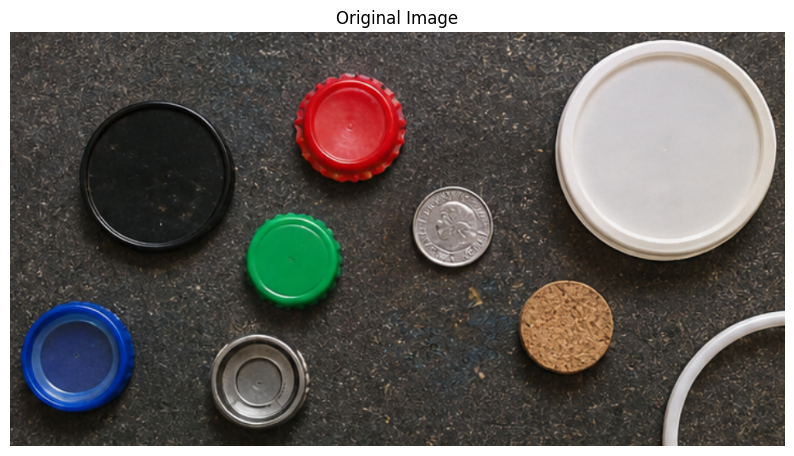

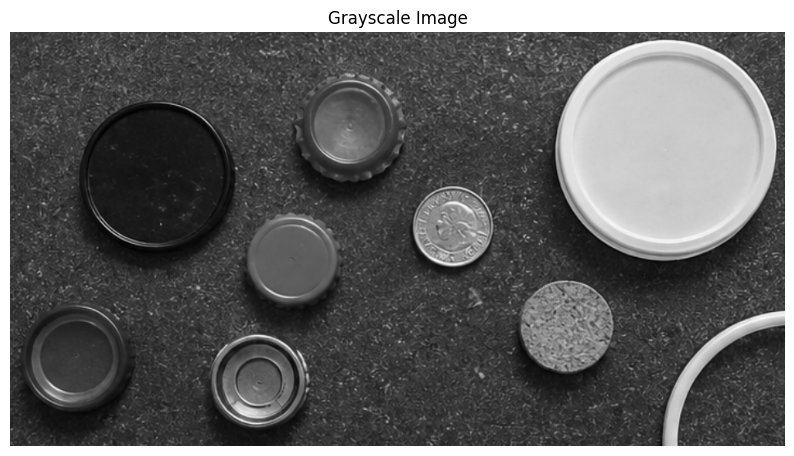

In [5]:

# Load image
image_bgr = cv2.imread(IMAGE_PATH)

if image_bgr is None:
    raise FileNotFoundError(
        f"Could not read '{IMAGE_PATH}'. "
        "Place the image in the notebook directory or update IMAGE_PATH."
    )

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print("Image shape:", image_rgb.shape)

plt.figure()
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

plt.figure()
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()



## 1. Preprocessing and Edge Detection

Circle detection works on an edge image. We first smooth the grayscale image to reduce noise and then detect edges using the Canny operator.


Number of edge pixels: 5577


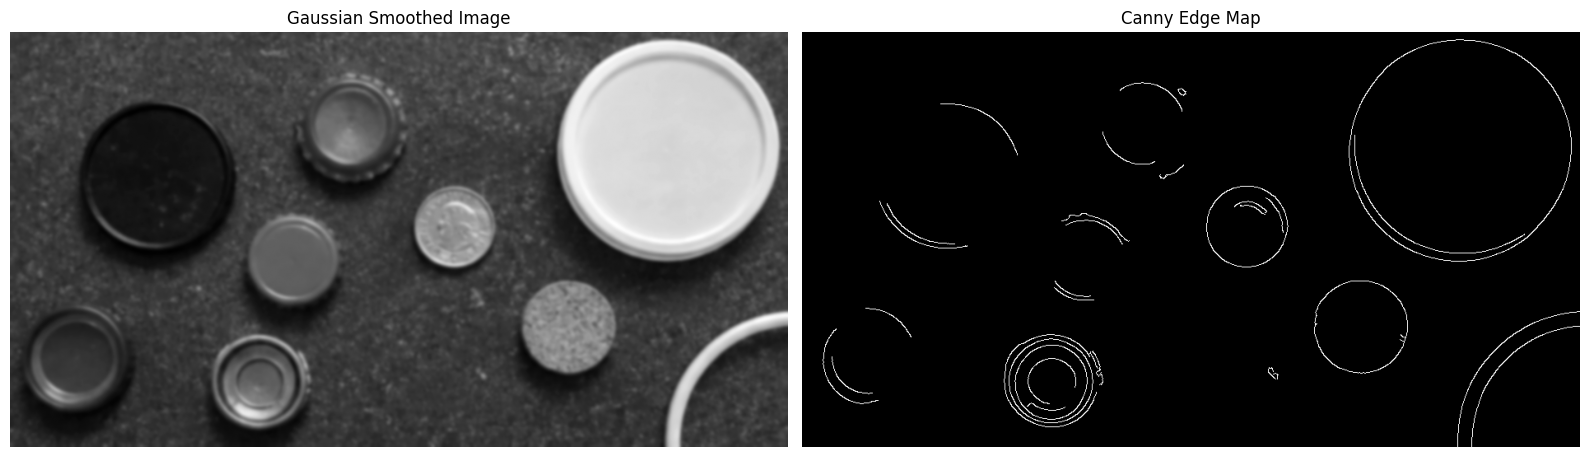

In [6]:

# Gaussian smoothing
blurred = cv2.GaussianBlur(
    gray,
    ksize=(0, 0),
    sigmaX=GAUSSIAN_SIGMA
)

# Canny edge detection
edges_cv = cv2.Canny(
    blurred,
    threshold1=CANNY_LOW,
    threshold2=CANNY_HIGH
)

# Convert to boolean for skimage
edges = edges_cv > 0

print("Number of edge pixels:", np.count_nonzero(edges))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(blurred, cmap="gray")
axes[0].set_title("Gaussian Smoothed Image")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Canny Edge Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()



## 2. Hough Transform for Circle Detection

For a circle,

$$
(x-a)^2 + (y-b)^2 = r^2
$$

where:
- $(a,b)$ is the center,
- $r$ is the radius.

The circle Hough Transform searches over possible centers and radii and accumulates votes from edge pixels.

We use `hough_circle()` and `hough_circle_peaks()` from `scikit-image`.


In [7]:

def detect_circles(edge_image, min_radius, max_radius,
                    threshold=0.4, max_circles=20):
    """Detect circles using the circular Hough Transform."""

    radii = np.arange(min_radius, max_radius + 1)

    # Hough accumulator
    hough_res = hough_circle(edge_image, radii)

    # Extract strongest peaks.
    # threshold is relative to the maximum accumulator response
    # when normalize=True.
    accums, cx, cy, detected_radii = hough_circle_peaks(
        hough_res,
        radii,
        total_num_peaks=max_circles,
        threshold=threshold,
        normalize=True,
        min_xdistance=MIN_CENTER_DISTANCE,
        min_ydistance=MIN_CENTER_DISTANCE
    )

    return accums, cx, cy, detected_radii, hough_res


In [8]:

def draw_circles(image, cx, cy, radii):
    """Draw detected circles on an RGB image."""

    result = image.copy()

    for x, y, r in zip(cx, cy, radii):
        cv2.circle(
            result,
            (int(x), int(y)),
            int(r),
            (255, 0, 0),
            2,
            cv2.LINE_AA
        )

        # Mark center
        cv2.circle(
            result,
            (int(x), int(y)),
            3,
            (0, 255, 0),
            -1
        )

    return result



## 3. Investigating Different Radius Ranges

The first experiment keeps the detection threshold fixed while changing the allowed radius range.

A radius range that is too narrow can cause **missed detections**. A very wide range increases the search space and can allow **false detections**, especially in noisy images.


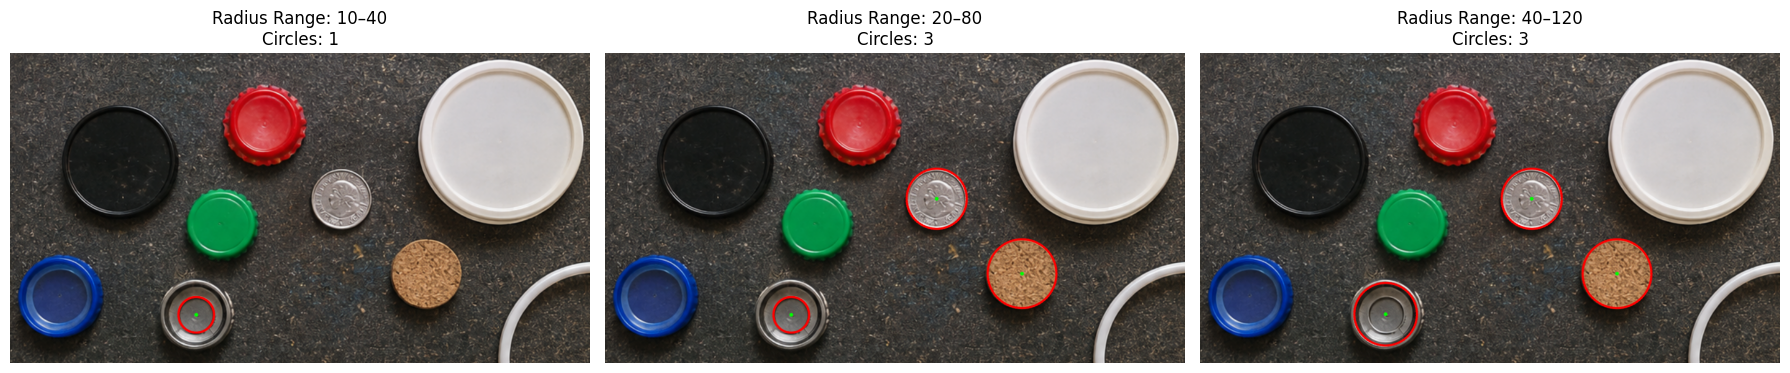

In [9]:

FIXED_THRESHOLD = 0.40

radius_results = []

for min_r, max_r in RADIUS_RANGES:
    accums, cx, cy, detected_radii, hough_res = detect_circles(
        edges,
        min_r,
        max_r,
        threshold=FIXED_THRESHOLD,
        max_circles=MAX_CIRCLES
    )

    overlay = draw_circles(
        image_rgb,
        cx,
        cy,
        detected_radii
    )

    radius_results.append({
        "min_radius": min_r,
        "max_radius": max_r,
        "accums": accums,
        "cx": cx,
        "cy": cy,
        "radii": detected_radii,
        "overlay": overlay,
        "hough_res": hough_res
    })

fig, axes = plt.subplots(
    1,
    len(radius_results),
    figsize=(18, 6)
)

for ax, result in zip(axes, radius_results):
    ax.imshow(result["overlay"])
    ax.set_title(
        f"Radius Range: {result['min_radius']}–{result['max_radius']}\n"
        f"Circles: {len(result['radii'])}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


In [10]:

# Print detected circles for each radius range
for result in radius_results:
    print(
        f"Radius range {result['min_radius']}–{result['max_radius']}: "
        f"{len(result['radii'])} circles"
    )

    for i, (x, y, r, score) in enumerate(
        zip(
            result["cx"],
            result["cy"],
            result["radii"],
            result["accums"]
        ),
        start=1
    ):
        print(
            f"  Circle {i}: center=({int(x)}, {int(y)}), "
            f"radius={int(r)}, score={score:.3f}"
        )

    print()


Radius range 10–40: 1 circles
  Circle 1: center=(303, 426), radius=29, score=0.506

Radius range 20–80: 3 circles
  Circle 1: center=(303, 426), radius=29, score=0.506
  Circle 2: center=(540, 237), radius=49, score=0.854
  Circle 3: center=(679, 359), radius=56, score=0.544

Radius range 40–120: 3 circles
  Circle 1: center=(540, 237), radius=49, score=0.854
  Circle 2: center=(302, 425), radius=51, score=0.730
  Circle 3: center=(679, 359), radius=56, score=0.544




## 4. Investigating Different Detection Thresholds

Now we fix the radius range and vary the Hough peak threshold.

- **Lower threshold:** more circles are accepted, increasing sensitivity but potentially producing false detections.
- **Higher threshold:** only stronger circle candidates are retained, reducing false detections but potentially missing weak, partial, or noisy circles.


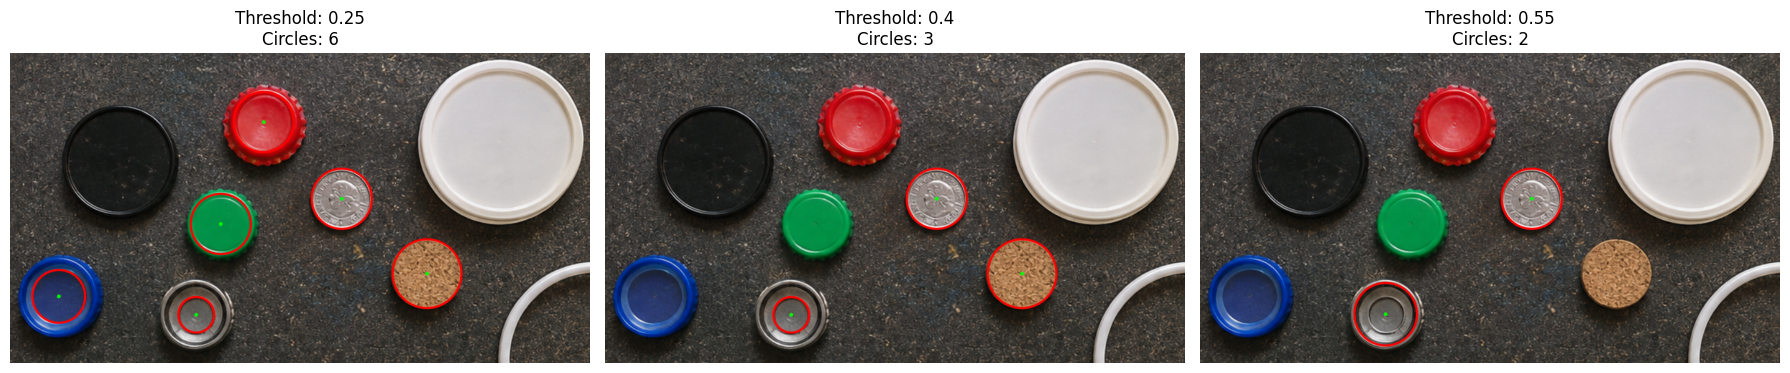

In [11]:

# Select the radius range that appears most suitable.
# CHANGE these values if your image requires a different range.
BEST_MIN_RADIUS = 20
BEST_MAX_RADIUS = 80

threshold_results = []

for threshold in PEAK_THRESHOLDS:
    accums, cx, cy, detected_radii, hough_res = detect_circles(
        edges,
        BEST_MIN_RADIUS,
        BEST_MAX_RADIUS,
        threshold=threshold,
        max_circles=MAX_CIRCLES
    )

    overlay = draw_circles(
        image_rgb,
        cx,
        cy,
        detected_radii
    )

    threshold_results.append({
        "threshold": threshold,
        "accums": accums,
        "cx": cx,
        "cy": cy,
        "radii": detected_radii,
        "overlay": overlay,
        "hough_res": hough_res
    })

fig, axes = plt.subplots(
    1,
    len(threshold_results),
    figsize=(18, 6)
)

for ax, result in zip(axes, threshold_results):
    ax.imshow(result["overlay"])
    ax.set_title(
        f"Threshold: {result['threshold']}\n"
        f"Circles: {len(result['radii'])}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


In [12]:

# Print threshold experiment results
for result in threshold_results:
    print(
        f"Threshold {result['threshold']}: "
        f"{len(result['radii'])} circles"
    )

    for i, (x, y, r, score) in enumerate(
        zip(
            result["cx"],
            result["cy"],
            result["radii"],
            result["accums"]
        ),
        start=1
    ):
        print(
            f"  Circle {i}: center=({int(x)}, {int(y)}), "
            f"radius={int(r)}, score={score:.3f}"
        )

    print()


Threshold 0.25: 6 circles
  Circle 1: center=(303, 426), radius=29, score=0.506
  Circle 2: center=(540, 237), radius=49, score=0.854
  Circle 3: center=(679, 359), radius=56, score=0.544
  Circle 4: center=(413, 112), radius=49, score=0.350
  Circle 5: center=(343, 278), radius=49, score=0.307
  Circle 6: center=(79, 396), radius=43, score=0.254

Threshold 0.4: 3 circles
  Circle 1: center=(303, 426), radius=29, score=0.506
  Circle 2: center=(540, 237), radius=49, score=0.854
  Circle 3: center=(679, 359), radius=56, score=0.544

Threshold 0.55: 2 circles
  Circle 1: center=(540, 237), radius=49, score=0.854
  Circle 2: center=(302, 425), radius=51, score=0.730




## 5. Final / Most Accurate Parameter Setting

After visually inspecting the experiments above, select the parameters that provide the best balance between:

- detecting the actual circular objects,
- avoiding duplicate circles,
- avoiding false circles caused by noise or other curved structures,
- detecting partial circles when enough of their boundary remains visible.

Update the values in the cell below if necessary.


Final parameter settings
------------------------
Minimum radius : 20
Maximum radius : 80
Threshold      : 0.4
Circles found  : 3


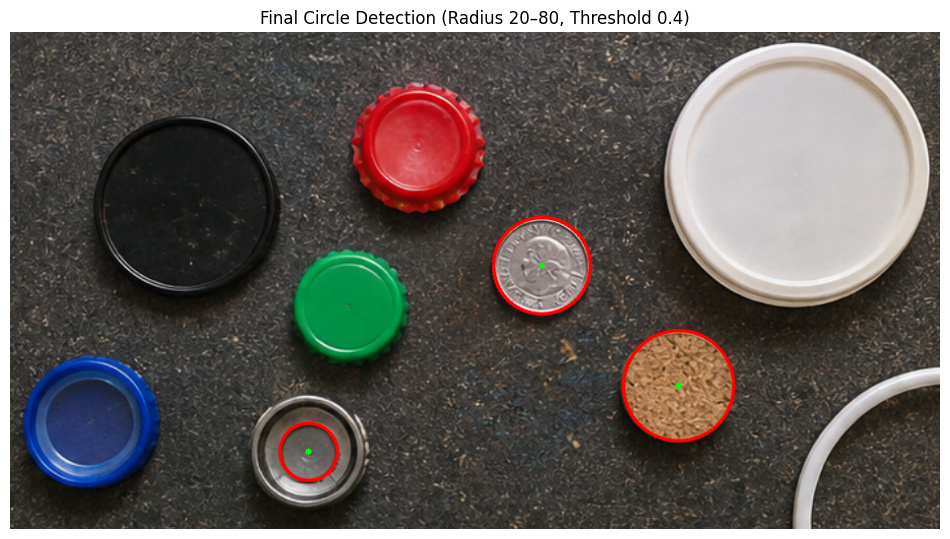

In [13]:

# -------------------------------------------------
# FINAL SELECTED PARAMETERS
# -------------------------------------------------
FINAL_MIN_RADIUS = 20
FINAL_MAX_RADIUS = 80
FINAL_THRESHOLD = 0.40

final_accums, final_cx, final_cy, final_radii, final_hough = detect_circles(
    edges,
    FINAL_MIN_RADIUS,
    FINAL_MAX_RADIUS,
    threshold=FINAL_THRESHOLD,
    max_circles=MAX_CIRCLES
)

final_overlay = draw_circles(
    image_rgb,
    final_cx,
    final_cy,
    final_radii
)

print("Final parameter settings")
print("------------------------")
print("Minimum radius :", FINAL_MIN_RADIUS)
print("Maximum radius :", FINAL_MAX_RADIUS)
print("Threshold      :", FINAL_THRESHOLD)
print("Circles found  :", len(final_radii))

plt.figure(figsize=(12, 8))
plt.imshow(final_overlay)
plt.title(
    f"Final Circle Detection "
    f"(Radius {FINAL_MIN_RADIUS}–{FINAL_MAX_RADIUS}, "
    f"Threshold {FINAL_THRESHOLD})"
)
plt.axis("off")
plt.show()


In [14]:

# Final detected circle table
print("Final detected circles:")
print("-" * 65)
print(f"{'No.':<5}{'Center (x,y)':<20}{'Radius':<12}{'Score':<10}")
print("-" * 65)

for i, (x, y, r, score) in enumerate(
    zip(final_cx, final_cy, final_radii, final_accums),
    start=1
):
    print(
        f"{i:<5}"
        f"({int(x)}, {int(y)}){'':<11}"
        f"{int(r):<12}"
        f"{score:.3f}"
    )


Final detected circles:
-----------------------------------------------------------------
No.  Center (x,y)        Radius      Score     
-----------------------------------------------------------------
1    (303, 426)           29          0.506
2    (540, 237)           49          0.854
3    (679, 359)           56          0.544



## 6. Discussion and Conclusion

### Effect of radius range

The radius range determines which circular objects can be detected.

- If the **minimum radius is too large**, small objects are missed.
- If the **maximum radius is too small**, large objects are missed.
- A very wide radius range increases computation and can introduce spurious detections because more possible circles are considered.

Therefore, the radius range should approximately cover the expected sizes of the circular objects.

### Effect of detection threshold

The Hough accumulator threshold controls how strong a candidate must be before it is considered a circle.

- A **low threshold** increases sensitivity and can recover weak or partial circles, but it may also produce false detections.
- A **high threshold** removes weak candidates and generally reduces false positives, but genuine circles with incomplete or noisy boundaries may be missed.

### Partial boundaries and noise

A complete circular boundary is not required for Hough detection because the available edge pixels can still vote for the correct center and radius. However, if too much of the boundary is missing, the accumulator peak becomes weaker and increasing the threshold can cause the circle to be missed.

Noise creates additional edge pixels that can vote for incorrect centers/radii, which may result in false detections. Gaussian smoothing and appropriate Canny thresholds help reduce this problem.

### Final conclusion

The most accurate parameter setting is the one that detects the actual circular objects while minimizing false positives and missed detections. For this image, the selected final parameters are:

- **Minimum radius:** `FINAL_MIN_RADIUS`
- **Maximum radius:** `FINAL_MAX_RADIUS`
- **Detection threshold:** `FINAL_THRESHOLD`

These values should be adjusted after visually comparing the experimental outputs for the particular input image.
